# CNN Demo: Klasifikacija slika (Fashion-MNIST)

Fashion-MNIST dataset (https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html)
    - slike 28×28 grayscale
    - 10 kategorija T-shirt, bag, sneaker, ...)

Dvije arhitekture:
1. Jednostavni CNN
2. ResNET18

+ GradCAM za vizualizaciju


## 1. Jednostavni CNN

- Input: 1-channel (grayscale) 28×28 image
- 2 konvolucijska sloja + ReLU activation + max pooling
- 1 potpuno povezani sloj (feature aggregation)
- Output: 10 (za svaku klasu)

Acc: 0.8997


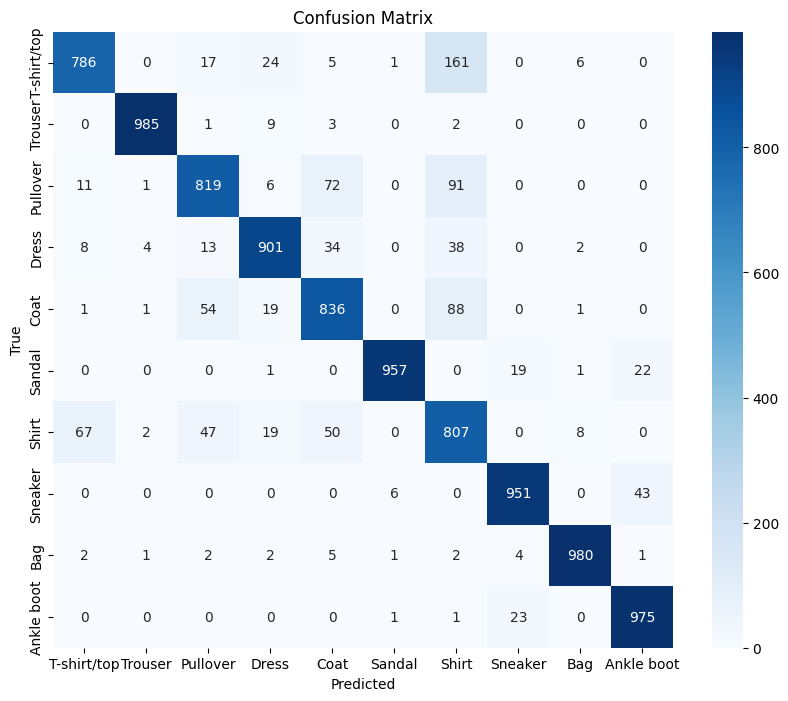

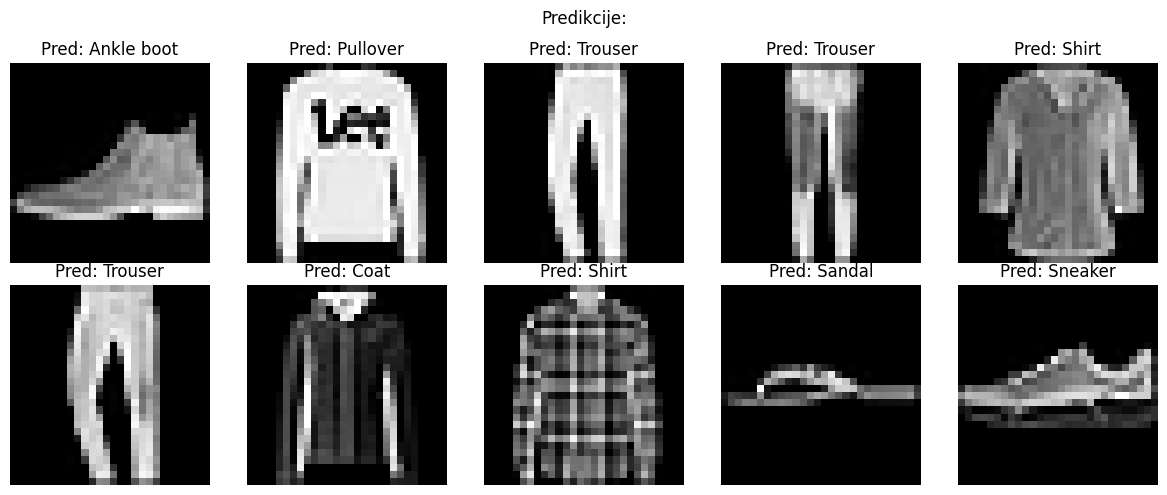

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import seaborn as sns


# dataset
transform = transforms.Compose([transforms.ToTensor()])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

# CNN arch
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


model.train()
for epoch in range(5):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# Eval
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Acc: {acc:.4f}")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_set.classes, yticklabels=test_set.classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


# neke predikcije
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

classes = train_set.classes
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axs.flatten()):
    img = images[i].cpu().squeeze()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {classes[preds[i]]}")
    ax.axis('off')

plt.suptitle("Predikcije:")
plt.tight_layout()
plt.show()


### Analiza klasificiranih primjeraka

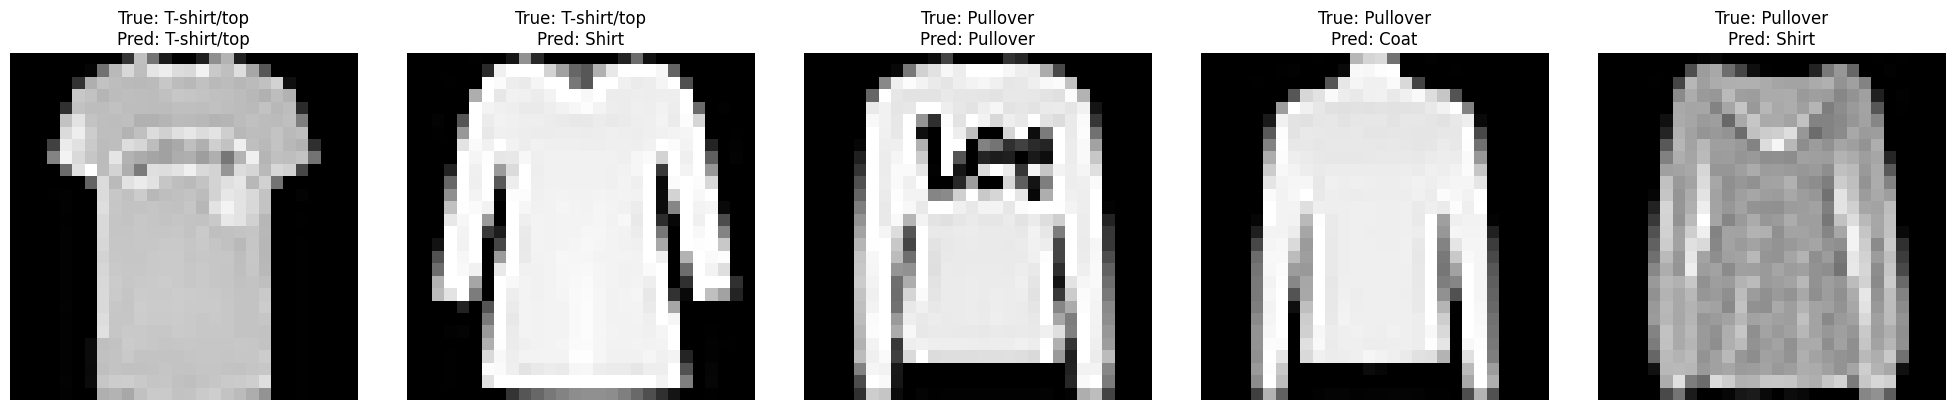

In [2]:
classes = train_set.classes

criteria = {
    "correct_tshirt": {"true": 0, "pred": 0},  # Correctly classified T-shirt/top
    "wrong_tshirt_as_shirt": {"true": 0, "pred": 6},  # T-shirt/top misclassified as Shirt
    "correct_pullover": {"true": 2, "pred": 2},  # Correctly classified Pullover
    "wrong_pullover_as_coat": {"true": 2, "pred": 4},  # Pullover misclassified as Coat
    "wrong_pullover_as_shirt": {"true": 2, "pred": 6},  # Pullover misclassified as Shirt
}


selected_indices = {key: None for key in criteria}
selected_images = {key: None for key in criteria}
selected_labels = {key: None for key in criteria}
selected_preds = {key: None for key in criteria}


for idx, (true, pred) in enumerate(zip(all_labels, all_preds)):
    for key, cond in criteria.items():
        if selected_indices[key] is None and true == cond["true"] and pred == cond["pred"]:
            selected_indices[key] = idx
            selected_labels[key] = true
            selected_preds[key] = pred

            if all(v is not None for v in selected_indices.values()):
                break


fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, (key, idx) in enumerate(selected_indices.items()):
    if idx is not None:
        img, true_label = test_set[idx]
        pred_label = selected_preds[key]
        ax = axs[i]
        ax.imshow(img.squeeze(), cmap="gray")
        ax.set_title(
            f"True: {classes[true_label]}\n"
            f"Pred: {classes[pred_label]}"
        )
        ax.axis("off")
    else:
        axs[i].set_title(f"Not found: {key}")
        axs[i].axis("off")


plt.tight_layout()
plt.show()

### Vizualizacija naučenih kernela (filtera) u prvom i drugom konv. sloju

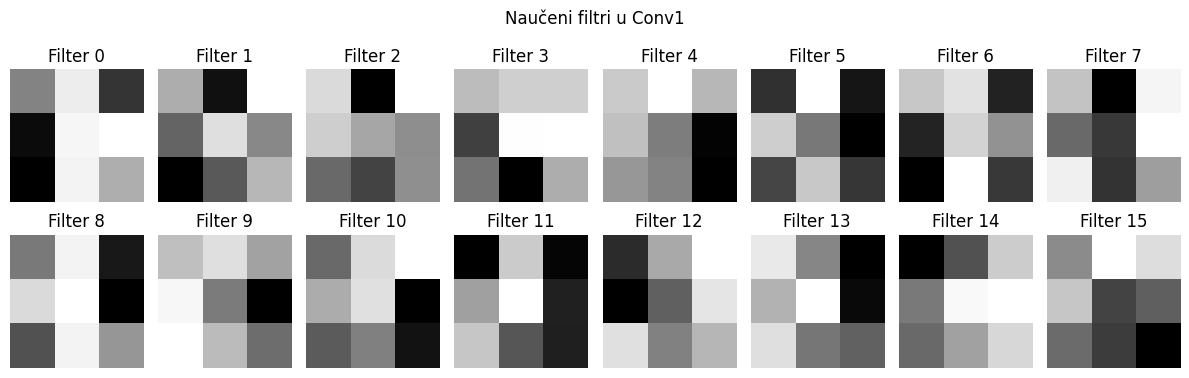

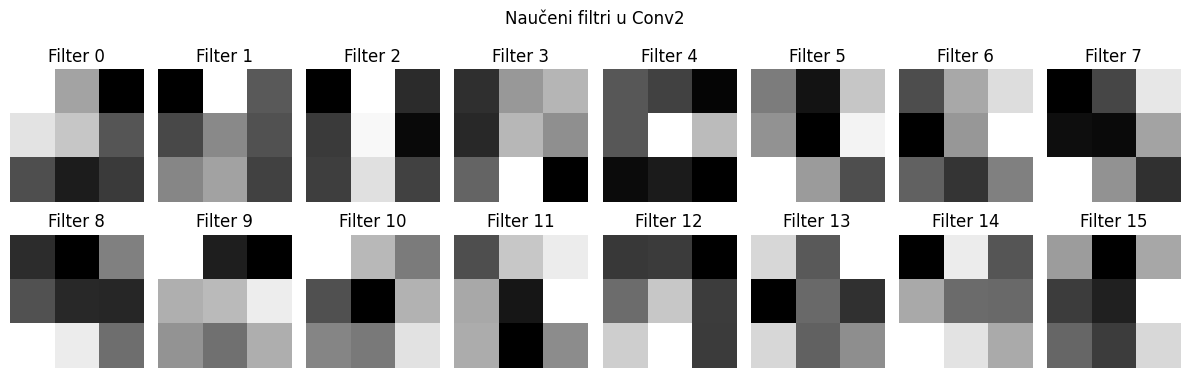

In [3]:
filters = model.conv1.weight.data.cpu()

fig, axs = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(filters[i][0], cmap='gray')
    ax.axis('off')
    ax.set_title(f"Filter {i}")

plt.suptitle("Naučeni filtri u Conv1")
plt.tight_layout()
plt.show()


filters2 = model.conv2.weight.data.cpu()

fig, axs = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(filters2[i][0], cmap='gray')
    ax.axis('off')
    ax.set_title(f"Filter {i}")

plt.suptitle("Naučeni filtri u Conv2")
plt.tight_layout()
plt.show()

### Aktivacije u Conv1 i Conv2

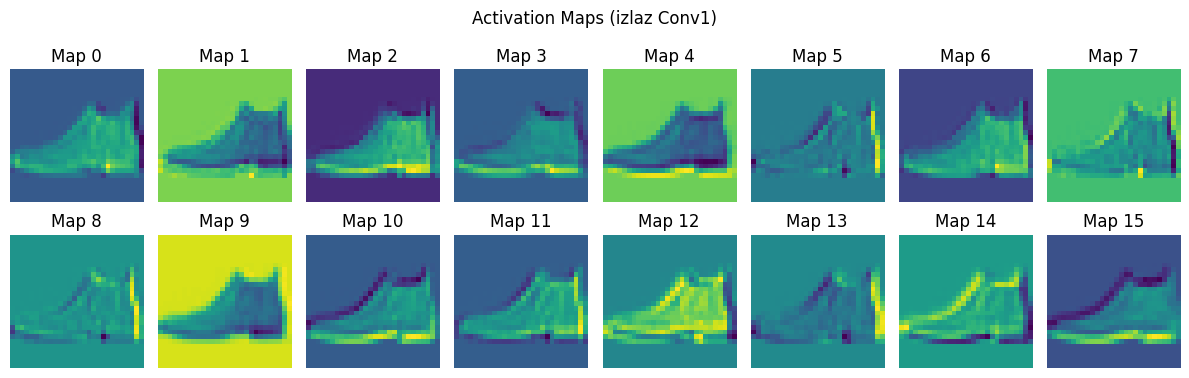

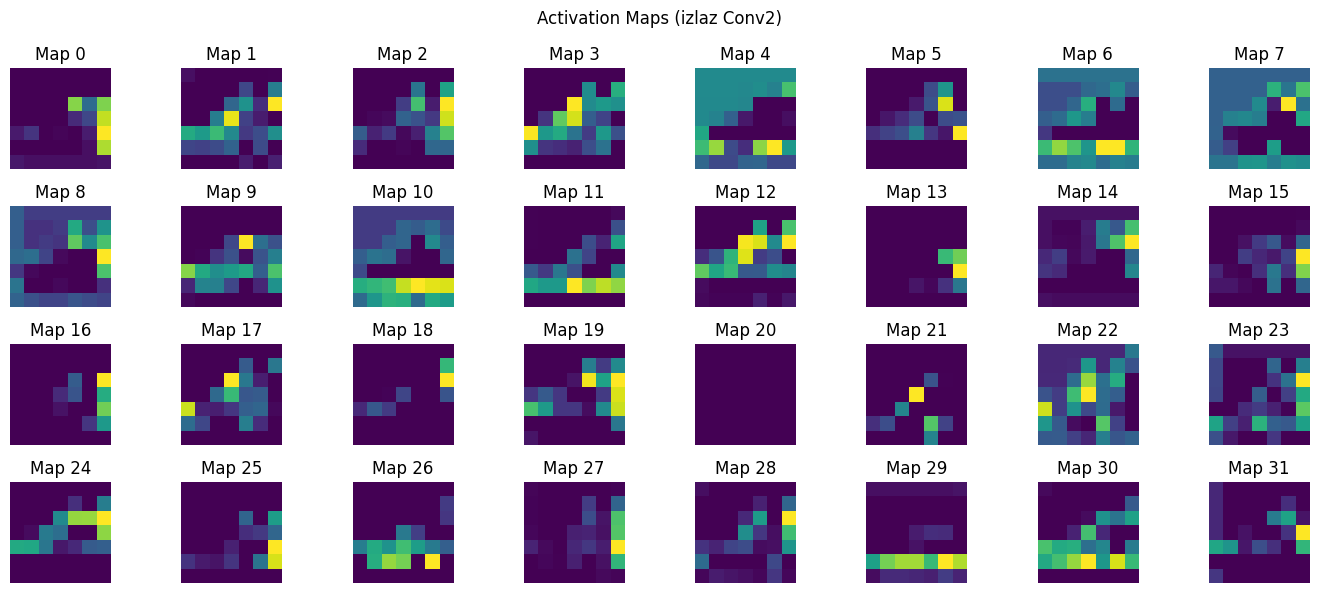

In [4]:
with torch.no_grad():
    image = images[0].unsqueeze(0).to(device)  # first test image
    activation = model.conv1(image)

fig, axs = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(activation[0, i].cpu(), cmap='viridis')
    ax.axis('off')
    ax.set_title(f"Map {i}")

plt.suptitle("Activation Maps (izlaz Conv1)")
plt.tight_layout()
plt.show()


with torch.no_grad():
    image = images[0].unsqueeze(0).to(device)
    x = model.pool(torch.relu(model.conv1(image)))
    conv2_output = model.pool(torch.relu(model.conv2(x)))

fig, axs = plt.subplots(4, 8, figsize=(14, 6))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(conv2_output[0, i].cpu(), cmap='viridis')
    ax.axis('off')
    ax.set_title(f"Map {i}")
plt.suptitle("Activation Maps (izlaz Conv2)")
plt.tight_layout()
plt.show()




### GradCAM

1. na sloju conv2
2. na sloju conv1

-boje: tamnoplavo-cijan(-); zeleno (neutralno); žuto-crveno(+)

In [5]:
import cv2
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

        # Register hooks
        self.hooks.append(target_layer.register_forward_hook(self.save_activation))
        self.hooks.append(target_layer.register_backward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        # Forward pass
        output = self.model(x)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        # Backward pass for the predicted class
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot)

        # Get pooled gradients
        pooled_gradients = torch.mean(self.gradients, dim=[2, 3], keepdim=True)

        # Weight the activations with the gradients
        weighted_activations = self.activations * pooled_gradients

        # Average over channels
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()
        #heatmap = torch.relu(heatmap)  # bolje radi bez ReLU-a

        # Normalize heatmap
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        heatmap = 2 * heatmap - 1  # Scale to [-1, 1]

        # Convert to [0, 255] for OpenCV colormap
        heatmap = (heatmap + 1) / 2  # [-1, 1] -> [0, 1]
        heatmap = heatmap.detach().cpu().numpy()
        heatmap = np.uint8(255 * heatmap)  # [0, 1] -> [0, 255]

        return heatmap, class_idx

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()




### conv2

C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


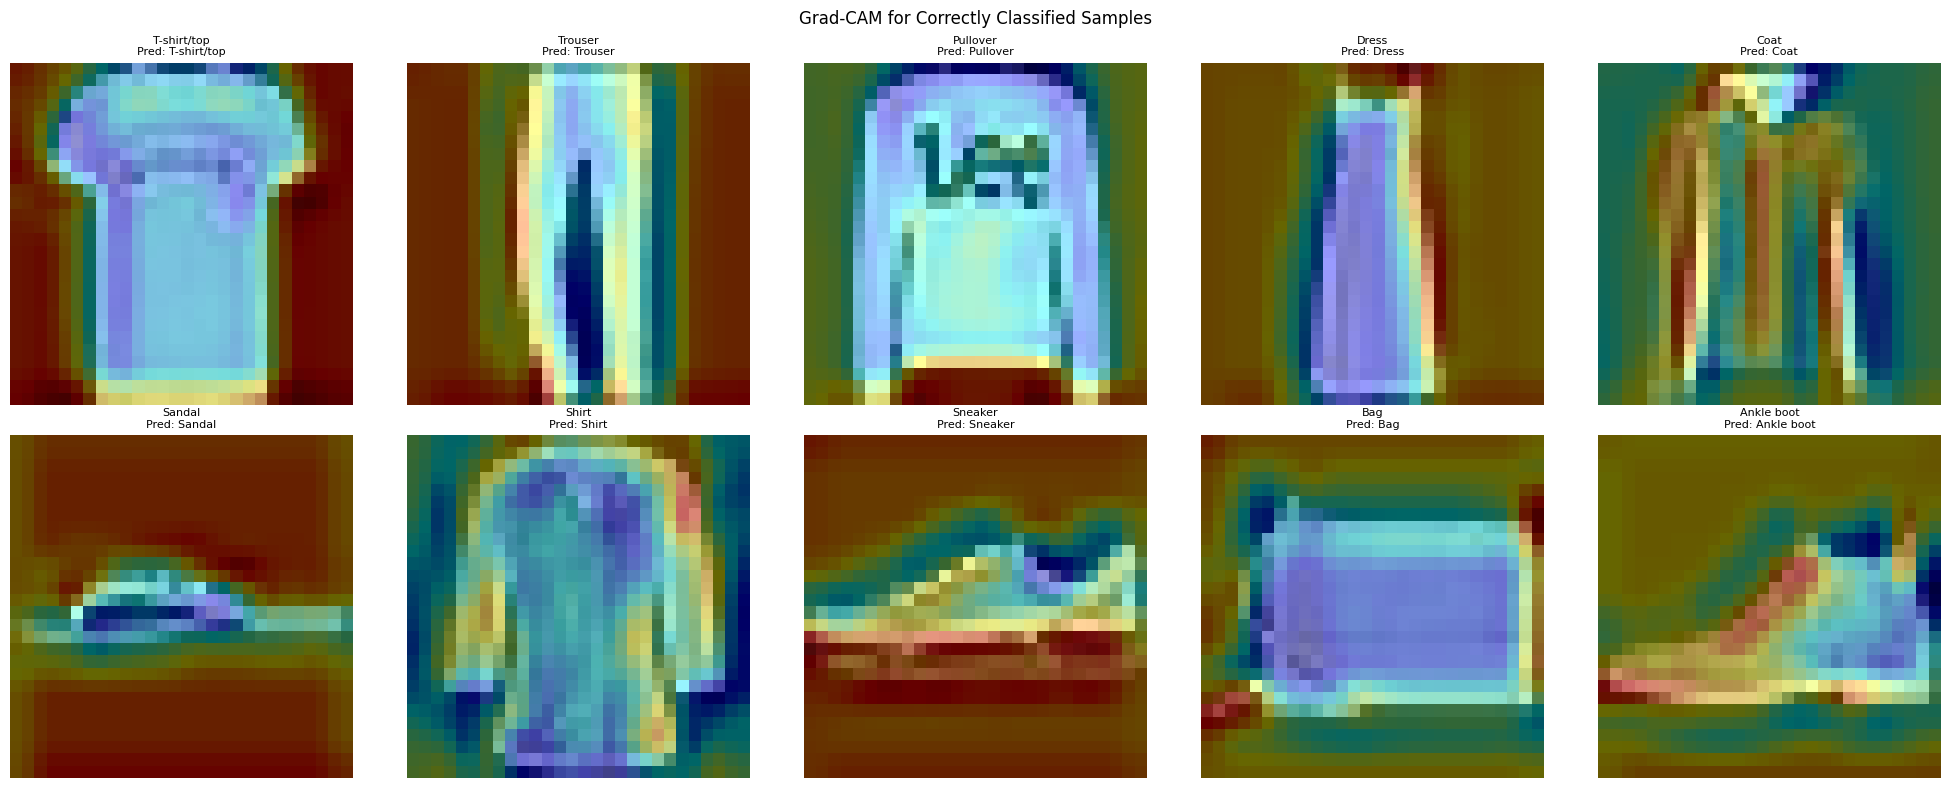

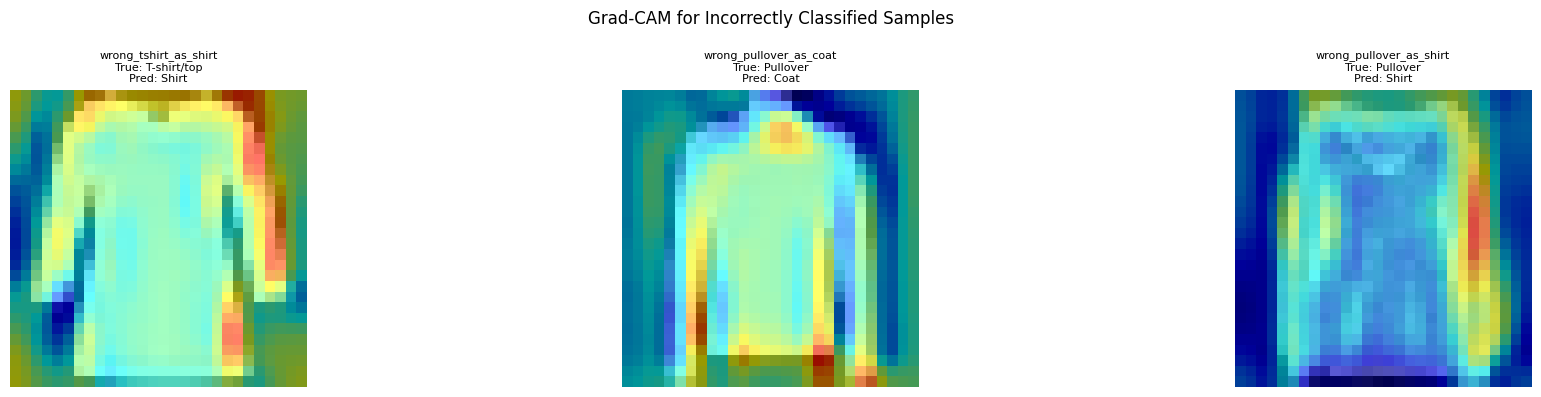

In [6]:
# --- Grad-CAM for selected samples ---
# prvo po jedan ispravni primjerak po klasi
classes = train_set.classes

correct_criteria = {
    f"correct_{classes[i]}": {"true": i, "pred": i}
    for i in range(10)
}
correct_indices = {key: None for key in correct_criteria}
correct_labels = {key: None for key in correct_criteria}
correct_preds = {key: None for key in correct_criteria}


for idx, (true, pred) in enumerate(zip(all_labels, all_preds)):
    for key, cond in correct_criteria.items():
        if correct_indices[key] is None and true == cond["true"] and pred == cond["pred"]:
            correct_indices[key] = idx
            correct_labels[key] = true
            correct_preds[key] = pred
            # Break early if all criteria are met
            if all(v is not None for v in correct_indices.values()):
                break



#onda neki specifični neispravni
incorr_criteria = {
    "wrong_tshirt_as_shirt": {"true": 0, "pred": 6},
    "wrong_pullover_as_coat": {"true": 2, "pred": 4},
    "wrong_pullover_as_shirt": {"true": 2, "pred": 6},
}


incorrect_indices = {key: None for key in incorr_criteria}
incorrect_images = {key: None for key in incorr_criteria}
incorrect_labels = {key: None for key in incorr_criteria}
incorrect_preds = {key: None for key in incorr_criteria}


for idx, (true, pred) in enumerate(zip(all_labels, all_preds)):
    for key, cond in incorr_criteria.items():
        if incorrect_indices[key] is None and true == cond["true"] and pred == cond["pred"]:
            incorrect_indices[key] = idx
            incorrect_labels[key] = true
            incorrect_preds[key] = pred

            if all(v is not None for v in incorrect_indices.values()):
                break



# init Grad-CAM for the last conv layer (conv2)
target_layer = model.conv2
grad_cam = GradCAM(model, target_layer)

fig_correct, axs_correct = plt.subplots(2, 5, figsize=(20, 8))
fig_correct.suptitle("Grad-CAM for Correctly Classified Samples")

for i, (key, idx) in enumerate(correct_indices.items()):
    if idx is not None:
        img, true_label = test_set[idx]
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img)
            pred_label = torch.argmax(output, dim=1).item()

        heatmap, _ = grad_cam(img, class_idx=pred_label)
        heatmap = cv2.resize(heatmap, (28, 28))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)


        img_np = img.squeeze().cpu().numpy()
        img_np = np.uint8(255 * img_np)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)

        superimposed_img = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

        row, col = i // 5, i % 5
        ax = axs_correct[row, col]
        ax.imshow(superimposed_img)
        ax.set_title(f"{classes[true_label]}\nPred: {classes[pred_label]}", fontsize=8)
        ax.axis("off")
    else:
        row, col = i // 5, i % 5
        axs_correct[row, col].set_title(f"Not found: {key}")
        axs_correct[row, col].axis("off")

grad_cam.remove_hooks()
plt.tight_layout()
plt.show()


#Grad-CAM for Incorrectly Classified Samples
grad_cam = GradCAM(model, target_layer)  # Reinitialize

fig_incorrect, axs_incorrect = plt.subplots(1, len(incorrect_indices), figsize=(20, 4))
fig_incorrect.suptitle("Grad-CAM for Incorrectly Classified Samples")

for i, (key, idx) in enumerate(incorrect_indices.items()):
    if idx is not None:
        img, true_label = test_set[idx]
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img)
            pred_label = torch.argmax(output, dim=1).item()

        heatmap, _ = grad_cam(img, class_idx=pred_label)
        heatmap = cv2.resize(heatmap, (28, 28))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        img_np = img.squeeze().cpu().numpy()
        img_np = np.uint8(255 * img_np)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)

        superimposed_img = cv2.addWeighted(img_np, 0.4, heatmap, 0.6, 0)

        ax = axs_incorrect[i] if len(incorrect_indices) > 1 else axs_incorrect
        ax.imshow(superimposed_img)
        ax.set_title(
            f"{key}\nTrue: {classes[true_label]}\nPred: {classes[pred_label]}",
            fontsize=8
        )
        ax.axis("off")
    else:
        ax = axs_incorrect[i] if len(incorrect_indices) > 1 else axs_incorrect
        ax.set_title(f"Not found: {key}")
        ax.axis("off")


grad_cam.remove_hooks()

plt.tight_layout()
plt.show()

### conv 1

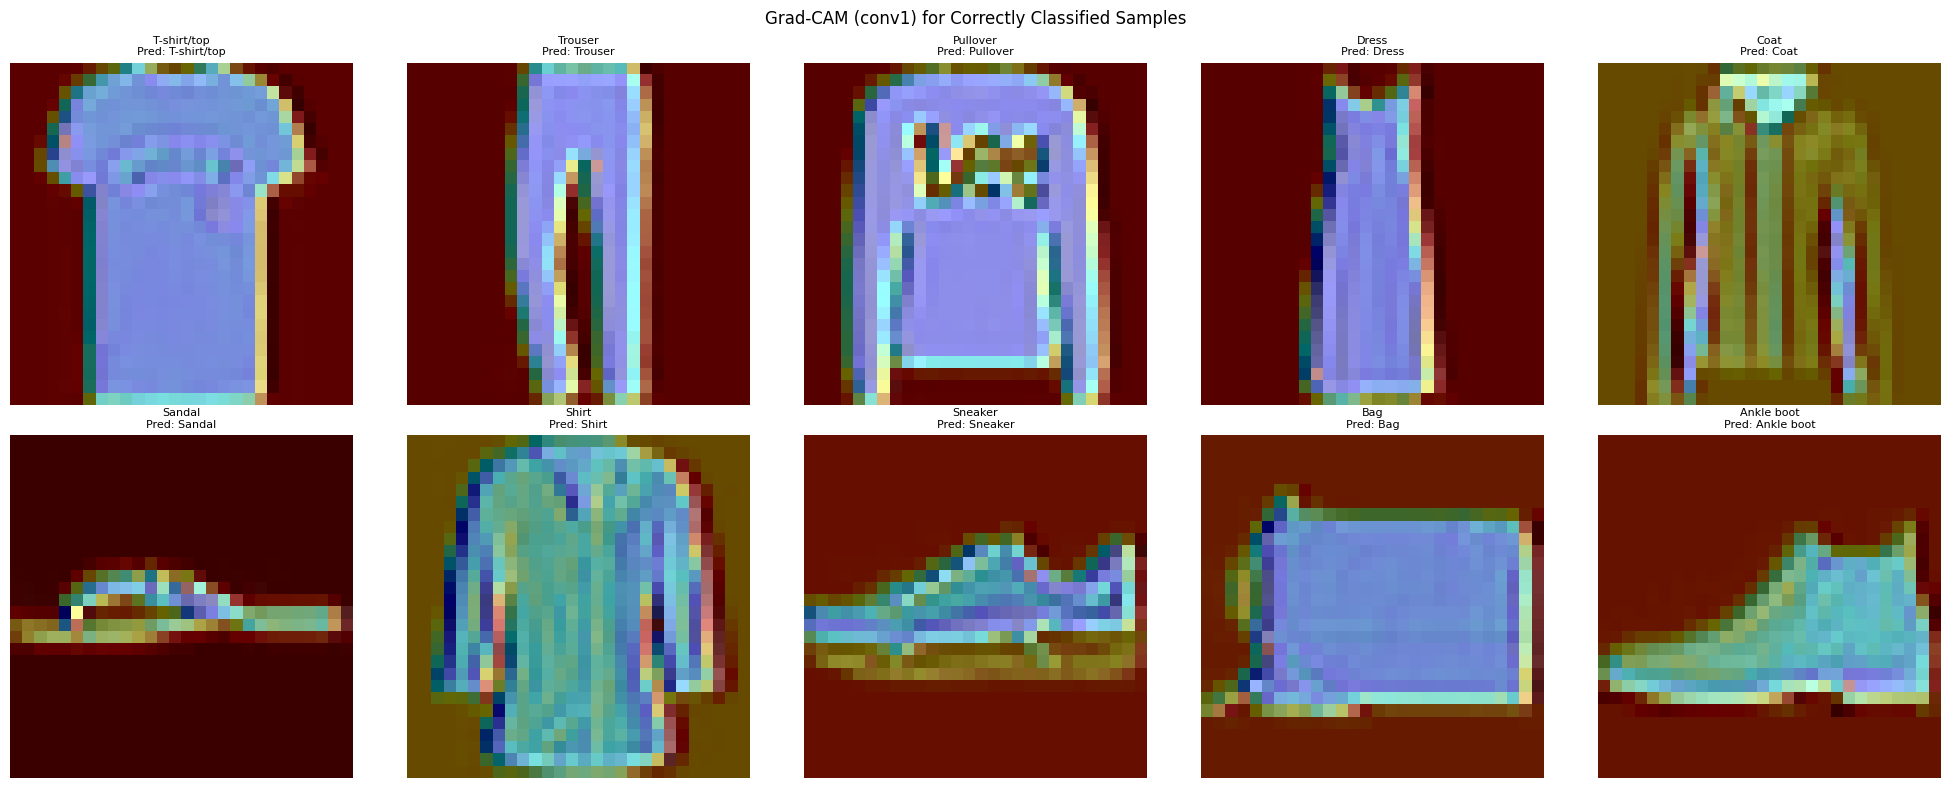

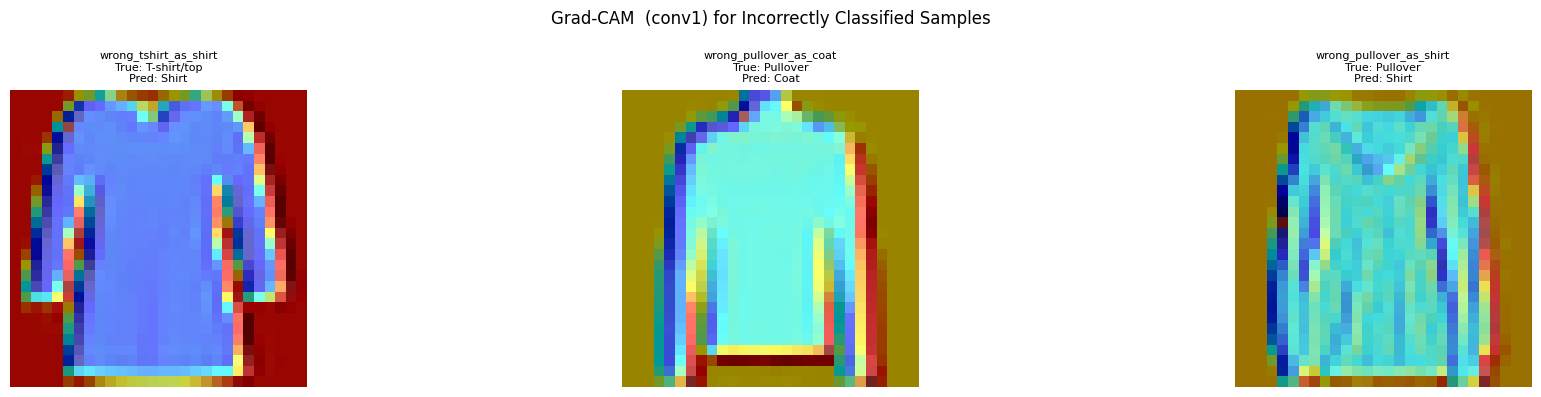

In [7]:

target_layer = model.conv1
grad_cam = GradCAM(model, target_layer)

fig_correct, axs_correct = plt.subplots(2, 5, figsize=(20, 8))
fig_correct.suptitle("Grad-CAM (conv1) for Correctly Classified Samples")

for i, (key, idx) in enumerate(correct_indices.items()):
    if idx is not None:
        img, true_label = test_set[idx]
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img)
            pred_label = torch.argmax(output, dim=1).item()

        heatmap, _ = grad_cam(img, class_idx=pred_label)
        heatmap = cv2.resize(heatmap, (28, 28))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        img_np = img.squeeze().cpu().numpy()
        img_np = np.uint8(255 * img_np)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)

        superimposed_img = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

        row, col = i // 5, i % 5
        ax = axs_correct[row, col]
        ax.imshow(superimposed_img)
        ax.set_title(f"{classes[true_label]}\nPred: {classes[pred_label]}", fontsize=8)
        ax.axis("off")
    else:
        row, col = i // 5, i % 5
        axs_correct[row, col].set_title(f"Not found: {key}")
        axs_correct[row, col].axis("off")

grad_cam.remove_hooks()  # Clean up before reusing
plt.tight_layout()
plt.show()

# --- 2. Grad-CAM for Incorrectly Classified Samples ---
grad_cam = GradCAM(model, target_layer)  # Reinitialize

fig_incorrect, axs_incorrect = plt.subplots(1, len(incorrect_indices), figsize=(20, 4))
fig_incorrect.suptitle("Grad-CAM  (conv1) for Incorrectly Classified Samples")

for i, (key, idx) in enumerate(incorrect_indices.items()):
    if idx is not None:
        img, true_label = test_set[idx]
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img)
            pred_label = torch.argmax(output, dim=1).item()

        heatmap, _ = grad_cam(img, class_idx=pred_label)
        heatmap = cv2.resize(heatmap, (28, 28))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        img_np = img.squeeze().cpu().numpy()
        img_np = np.uint8(255 * img_np)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)

        superimposed_img = cv2.addWeighted(img_np, 0.4, heatmap, 0.6, 0)

        ax = axs_incorrect[i] if len(incorrect_indices) > 1 else axs_incorrect
        ax.imshow(superimposed_img)
        ax.set_title(
            f"{key}\nTrue: {classes[true_label]}\nPred: {classes[pred_label]}",
            fontsize=8
        )
        ax.axis("off")
    else:
        ax = axs_incorrect[i] if len(incorrect_indices) > 1 else axs_incorrect
        ax.set_title(f"Not found: {key}")
        ax.axis("off")

# Clean up hooks
grad_cam.remove_hooks()

plt.tight_layout()
plt.show()

## 2. ResNET18
- za usporedbu točnosti i kako radi GradCAM

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision.models import resnet18

# --- ResNet for MNIST (1-channel input) ---
class MNISTResNet(nn.Module):
    def __init__(self):
        super(MNISTResNet, self).__init__()
        # resnet-ov orig. dataset nije baš sličan ovome pa nećemo koristiti naučene težine nego idemo ispočetka
        self.model = resnet18(pretrained=False)
        # Change first conv layer to accept 1-channel input
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        # Remove the first maxpool (not needed for 28x28 images)
        self.model.maxpool = nn.Identity()
        # Change final layer to 10 classes (MNIST)
        self.model.fc = nn.Linear(512, 10)

    def forward(self, x):
        return self.model(x)

# --- Dataset and DataLoader ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # FashionMNIST mean and std
])

train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNISTResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


model.train()
for epoch in range(5):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1, Loss: 0.3426
Epoch 2, Loss: 0.4248
Epoch 3, Loss: 0.1719
Epoch 4, Loss: 0.1317
Epoch 5, Loss: 0.1556


In [14]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

        self.hooks.append(target_layer.register_forward_hook(self.save_activation))
        self.hooks.append(target_layer.register_backward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        output = self.model(x)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot)

        # Use absolute gradients (no ReLU)
        pooled_gradients = torch.mean(torch.abs(self.gradients), dim=[2, 3], keepdim=True)
        weighted_activations = self.activations * pooled_gradients
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        return heatmap.detach().cpu().numpy(), class_idx

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

Acc: 0.9254


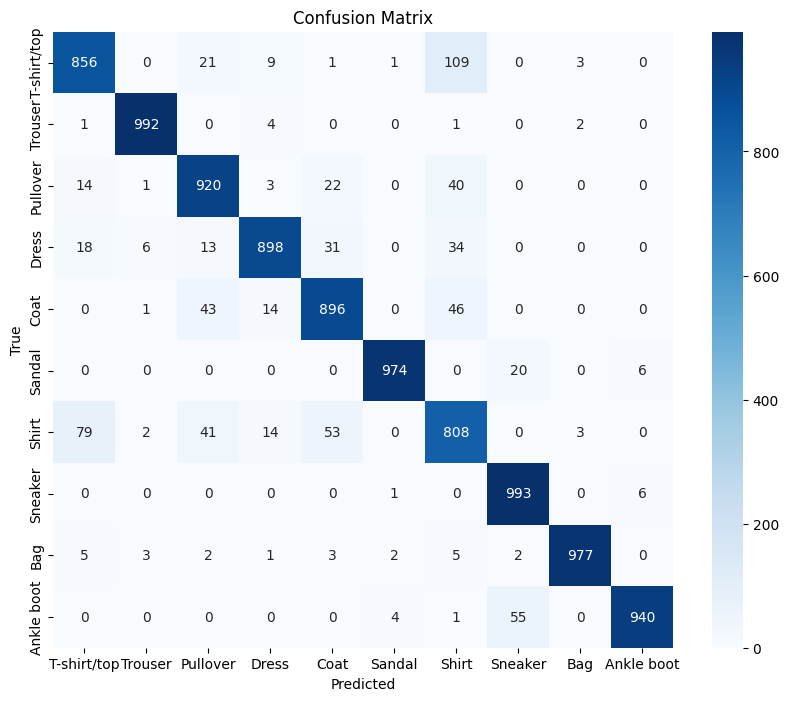

In [15]:
# --- Evaluate and collect samples ---
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())


acc = accuracy_score(all_labels, all_preds)
print(f"Acc: {acc:.4f}")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_set.classes, yticklabels=test_set.classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


# --- Collect correct and incorrect indices ---
correct_indices = {}
incorrect_indices = []

for idx, (true, pred) in enumerate(zip(all_labels, all_preds)):
    if true == pred and true not in correct_indices:
        correct_indices[true] = idx  # One correct sample per class
    elif true != pred:
        incorrect_indices.append(idx)  # All misclassified samples

# Select up to 5 misclassified samples
incorrect_indices = incorrect_indices[:5]

C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


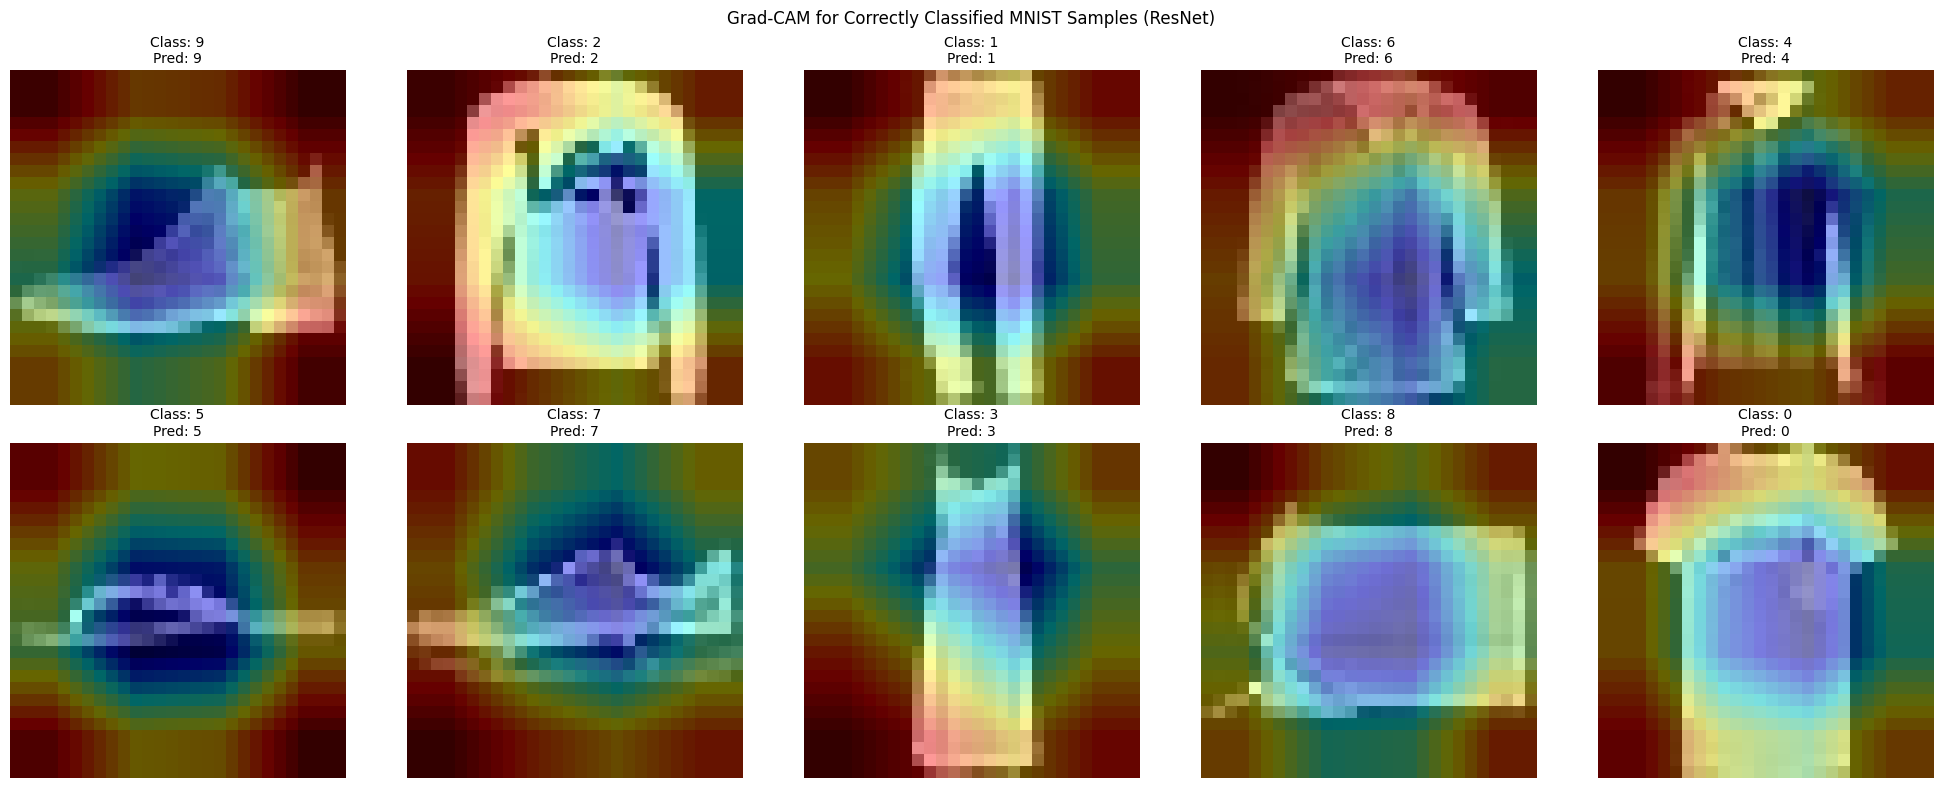

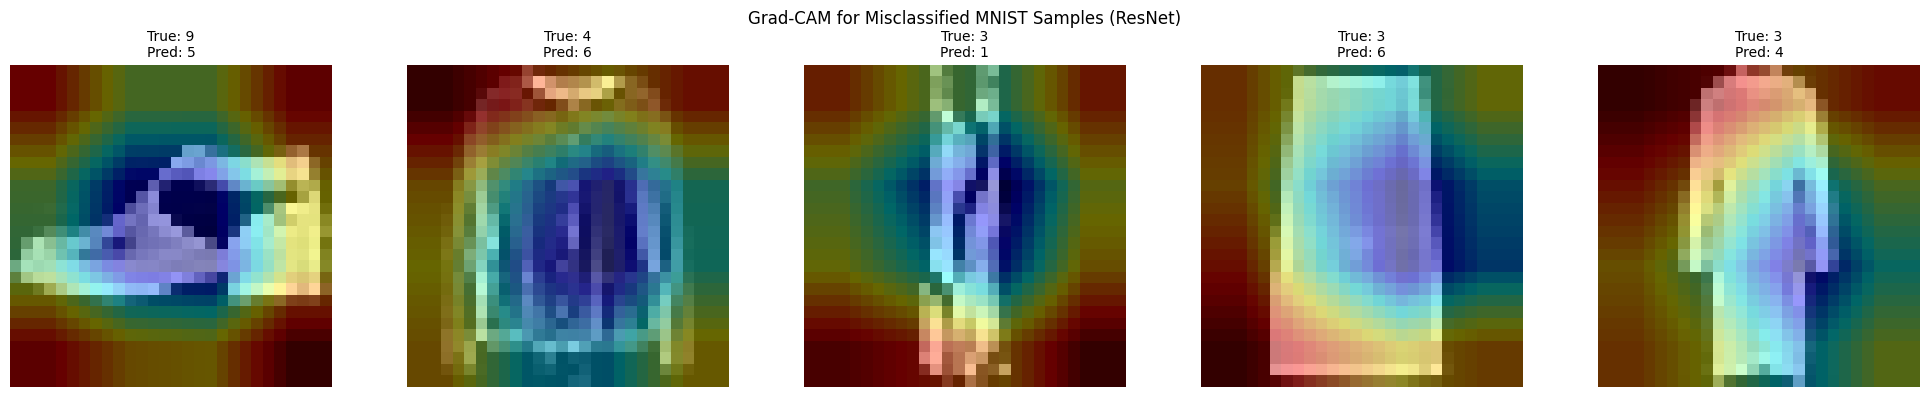

In [16]:
# --- Grad-CAM for Correctly Classified Samples ---
target_layer = model.model.layer4[-1].conv2  # Last conv layer in ResNet18
grad_cam = GradCAM(model, target_layer)

fig_correct, axs_correct = plt.subplots(2, 5, figsize=(20, 8))
fig_correct.suptitle("Grad-CAM for Correctly Classified MNIST Samples (ResNet)")

for i, (class_idx, idx) in enumerate(correct_indices.items()):
    img, true_label = test_set[idx]
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        pred_label = torch.argmax(output, dim=1).item()

    heatmap, _ = grad_cam(img, class_idx=pred_label)
    heatmap = cv2.resize(heatmap, (28, 28))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img_np = img.squeeze().cpu().numpy()
    img_np = np.uint8(255 * (img_np - img_np.min()) / (img_np.max() - img_np.min()))  # Denormalize
    img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)

    superimposed_img = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    row, col = i // 5, i % 5
    ax = axs_correct[row, col]
    ax.imshow(superimposed_img)
    ax.set_title(f"Class: {class_idx}\nPred: {pred_label}", fontsize=10)
    ax.axis("off")

grad_cam.remove_hooks()
plt.tight_layout()
plt.show()

# --- Grad-CAM for Misclassified Samples ---
grad_cam = GradCAM(model, target_layer)

fig_incorrect, axs_incorrect = plt.subplots(1, len(incorrect_indices), figsize=(20, 4))
fig_incorrect.suptitle("Grad-CAM for Misclassified MNIST Samples (ResNet)")

for i, idx in enumerate(incorrect_indices):
    img, true_label = test_set[idx]
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        pred_label = torch.argmax(output, dim=1).item()

    heatmap, _ = grad_cam(img, class_idx=pred_label)
    heatmap = cv2.resize(heatmap, (28, 28))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img_np = img.squeeze().cpu().numpy()
    img_np = np.uint8(255 * (img_np - img_np.min()) / (img_np.max() - img_np.min()))
    img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)

    superimposed_img = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    ax = axs_incorrect[i] if len(incorrect_indices) > 1 else axs_incorrect
    ax.imshow(superimposed_img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    ax.axis("off")

grad_cam.remove_hooks()
plt.tight_layout()
plt.show()